# Notebook 8 | Probability Tree

In [1]:
from foundations_of_probability_and_statistics.cars.car_distribution import create_joint_car_distribution

import matplotlib.pyplot as plt
import pandas as pd

# show all rows of data frames and series per default
pd.set_option("display.max_rows", None)

## The tree as nested product rule: seeing the factorization

How do we hold the whole factorization of notebook 1 in one picture? Draw it level by level: brand edges from the root (notebook 7: a partition), then color edges per brand. In full form first,

$$p(B = b, H = h, C = c) = p(b) \, p(h \mid b) \, p(c \mid b),$$

then the shorthand $p(b, h, c)$. A root-to-leaf path product is the joint probability of that leaf; summing leaves is marginalization (notebook 2); reading the tree backwards from leaf to root is Bayes (notebook 9). The same drawing is the mental model of ancestral sampling in notebooks 10-14 -- and later, of Bayes filters: walk down the tree, sampling one edge at a time.

## Derivation

1. Root splits into brands with edge weights $p(b)$: $0.5$, $0.3$, $0.2$ -- the partition of notebook 7.
2. Each brand node splits into colors with edge weights $p(c \mid b)$, e.g. VW to gray with $0.5$.
3. A path product gives the leaf: $p(\text{VW} \to \text{gray}) = 0.5 \cdot 0.5 = 0.25$.
4. Summing the leaves of one color gives the marginal, e.g. $p(\text{red}) = 0.2 \cdot 0.6 = 0.12$ (notebook 2 again).

The characteristic mistake is reading edge weights as leaf probabilities: the edge says $p(c \mid b)$, the leaf says $p(b) \, p(c \mid b)$. Forgetting the $p(b)$ factor is conditioning without renormalizing in disguise.

## Worked example (by hand)

Path product down the VW branch -- follow the edges and multiply:

$$p(\text{VW} \to \text{gray}) = 0.5 \cdot 0.5 = 0.25.$$

Leaf sum for red, reached only through Ferrari -- collect every leaf painted red:

$$p(\text{red}) = 0.2 \cdot 0.6 = 0.12.$$

One path versus all paths to a color: the product rule and the law of total probability as two readings of the same drawing.

In [2]:
import math

joint = create_joint_car_distribution()

# path product: p(VW -> gray) = p(VW) p(gray | VW)
assert math.isclose(0.5 * 0.5, 0.25)
assert math.isclose(joint.xs("VW", level="brand").xs("gray", level="color").sum(), 0.25)

# leaf sum: p(red) = p(Ferrari) p(red | Ferrari)
assert math.isclose(0.2 * 0.6, 0.12)
assert math.isclose(joint.xs("red", level="color").sum(), 0.12)
joint.xs("red", level="color").sum()

np.float64(0.12)

## Generalization

Two genuine node-link trees below, drawn inline with matplotlib (deterministic layout, one hue per brand). The first shows the full brand-to-color tree: all 10 color leaves with edge labels $p(c \mid b)$ and leaf labels carrying the path product $p(b) \, p(c \mid b)$. The second zooms into the worked example: the VW-to-gray path highlighted and the red-leaf collection annotated as the marginal sum $0.12$. What to see: products along paths, sums across leaves. What the display compresses: the horsepower layer is folded away -- each color edge already marginalizes over it.

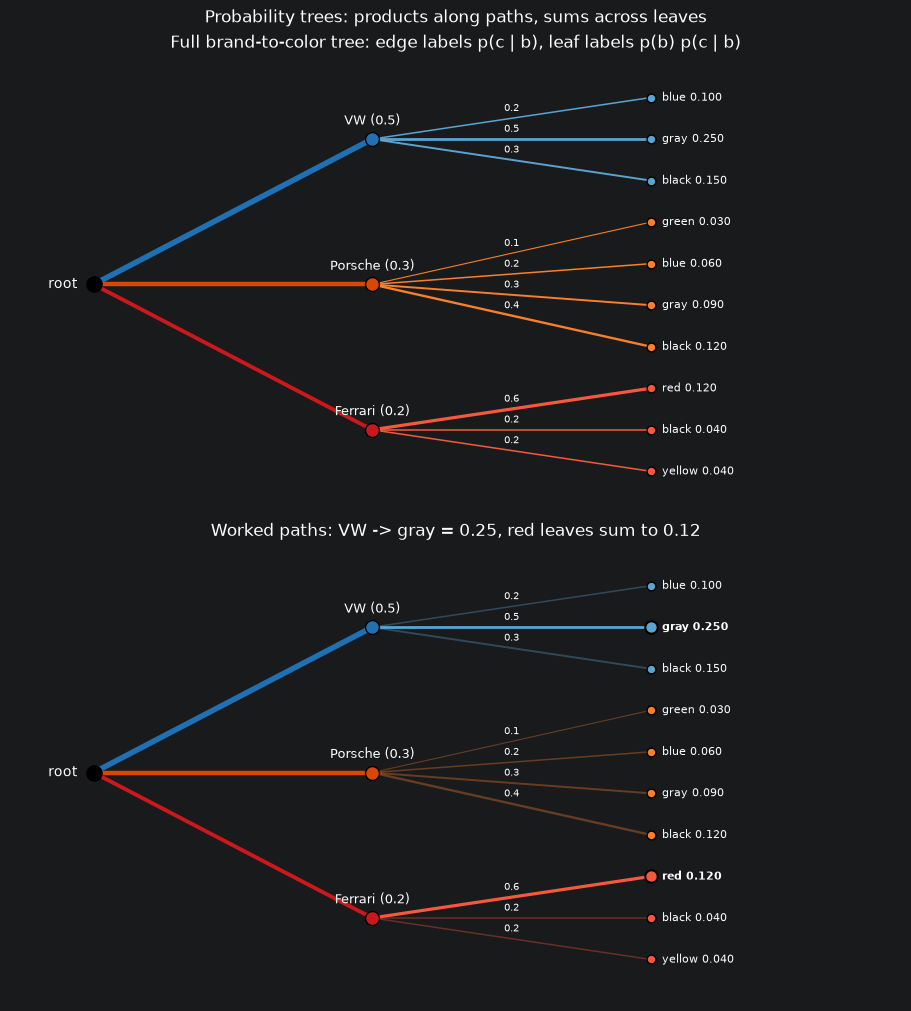

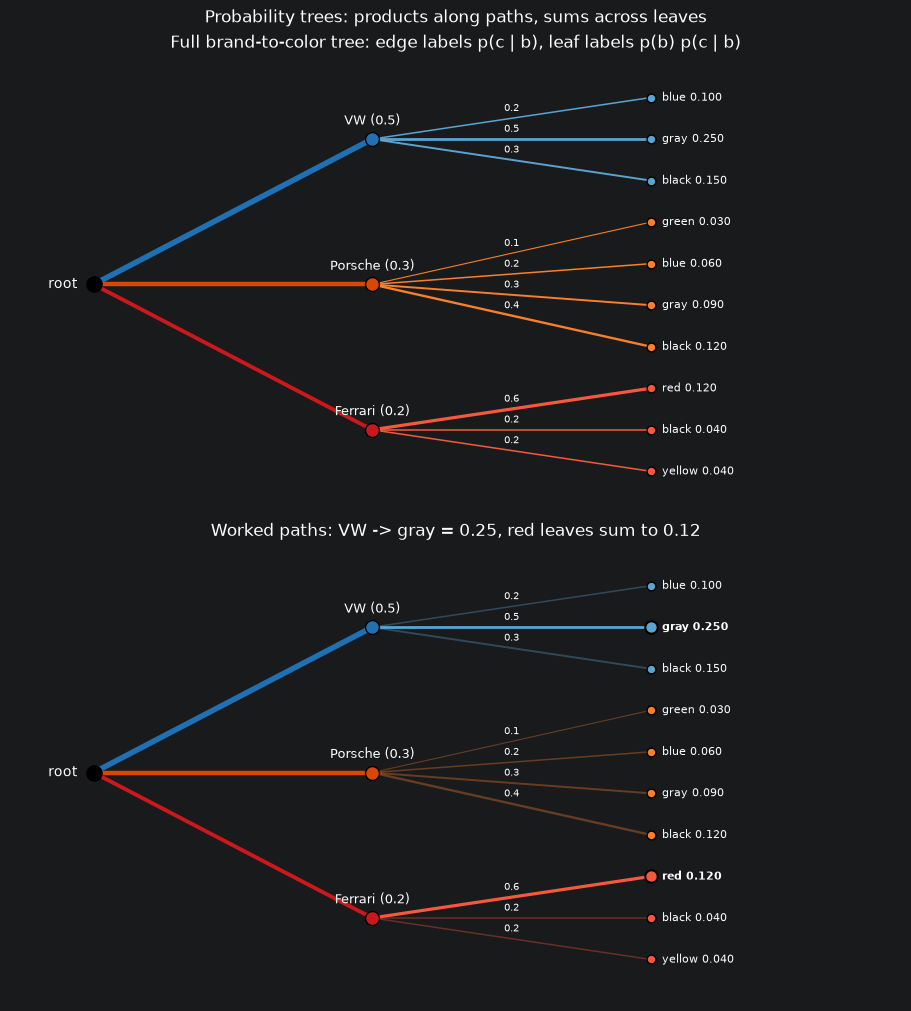

In [3]:
import matplotlib
import matplotlib.pyplot as plt

brand_priors = {"VW": 0.5, "Porsche": 0.3, "Ferrari": 0.2}
brand_color_probs = {
    "VW": {"blue": 0.2, "gray": 0.5, "black": 0.3},
    "Porsche": {"green": 0.1, "blue": 0.2, "gray": 0.3, "black": 0.4},
    "Ferrari": {"red": 0.6, "black": 0.2, "yellow": 0.2},
}
brand_cmaps = {"VW": "Blues", "Porsche": "Oranges", "Ferrari": "Reds"}

# deterministic node-link layout: fixed depth columns, evenly spaced leaves
leaves = [(brand, color) for brand in ["VW", "Porsche", "Ferrari"] for color in brand_color_probs[brand]]
leaf_y = {leaf: len(leaves) - 1 - i for i, leaf in enumerate(leaves)}
brand_y = {brand: sum(leaf_y[(brand, c)] for c in brand_color_probs[brand]) / len(brand_color_probs[brand]) for brand in brand_priors}
ROOT, BRAND_X, LEAF_X = 0.0, 1.0, 2.0


def draw_tree(ax, highlight=None, title=""):
    # nodes and edges of the brand -> color tree with path-product leaf labels
    ax.scatter([ROOT], [4.5], s=120, color="black", zorder=3)
    ax.text(ROOT - 0.06, 4.5, "root", ha="right", va="center", fontsize=10)
    for brand, prior in brand_priors.items():
        cmap = matplotlib.colormaps[brand_cmaps[brand]]
        ax.scatter([BRAND_X], [brand_y[brand]], s=100, color=cmap(0.75), edgecolors="black", zorder=3)
        ax.text(BRAND_X, brand_y[brand] + 0.28, f"{brand} ({prior})", ha="center", va="bottom", fontsize=9)
        ax.plot([ROOT, BRAND_X], [4.5, brand_y[brand]], color=cmap(0.75), linewidth=2.0 + 4.0 * prior)
        for color, cond in brand_color_probs[brand].items():
            y = leaf_y[(brand, color)]
            path = prior * cond
            is_hot = highlight is not None and (brand, color) in highlight
            ax.scatter([LEAF_X], [y], s=80 if is_hot else 40, color=cmap(0.55), edgecolors="black", linewidth=1.5 if is_hot else 1.0, zorder=3)
            ax.plot([BRAND_X, LEAF_X], [brand_y[brand], y], color=cmap(0.55), linewidth=3.0 * cond + 0.5, alpha=1.0 if is_hot or highlight is None else 0.35)
            ax.text((BRAND_X + LEAF_X) / 2, (brand_y[brand] + y) / 2 + 0.12, f"{cond}", ha="center", va="bottom", fontsize=7)
            ax.text(LEAF_X + 0.04, y, f"{color} {path:.3f}", ha="left", va="center", fontsize=8, weight="bold" if is_hot else "normal")
    ax.set_xlim(-0.3, 2.9)
    ax.set_ylim(-1.0, 10.0)
    ax.axis("off")
    ax.set_title(title)


figure, axes = plt.subplots(2, 1, figsize=(9.0, 10.0), dpi=100, layout="constrained")
draw_tree(axes[0], title="Full brand-to-color tree: edge labels p(c | b), leaf labels p(b) p(c | b)")
# worked path VW -> gray (0.25) plus the red-leaf collection summing to 0.12
draw_tree(axes[1], highlight={("VW", "gray"), ("Ferrari", "red")}, title="Worked paths: VW -> gray = 0.25, red leaves sum to 0.12")
figure.suptitle("Probability trees: products along paths, sums across leaves")
figure

## References

- Blitzstein, J. K., Hwang, J. (2019): "Introduction to Probability", 2nd ed., Chapman & Hall/CRC, chapter "Conditional Probability", https://www.routledge.com/Introduction-to-Probability-Second-Edition/Blitzstein-Hwang/p/book/9781138369917 (free PDF: https://probabilitybook.net/).
- Wasserman, L. (2004): "All of Statistics: A Concise Course in Statistical Inference", Springer Texts in Statistics, chapter "Probability", https://doi.org/10.1007/978-0-387-21736-9.
- scipy.stats.rv_discrete, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html.